# 02 — Regime Model (Man Group Replication)

Replicates the Man Group paper methodology and tests it across applications:

**Regime model:**
1. Transform 8 macro variables to z-scores (12m change, rolling 10yr window, winsorized ±3)
2. Compute Euclidean distance (Global Score) between today and every historical month
3. Exclude recent 36 months to avoid momentum loading
4. Select top 15% most similar months → look at subsequent asset returns

**Tests (from paper):**
- S&P 500 L/S timing → Failed (equity drift kills shorts)
- FF factor timing (quintile 1 vs 5) → Sharpe 0.82 (paper's main result)

**Additional tests (extensions):**
- S&P 500 cash rotation → Sharpe 0.54
- S&P 500 equity/bond rotation → Sharpe 0.51
- Factor ETF portfolio with regime tilts → Sharpe 0.76
- Long-only top factors → Sharpe 0.79

Loaded: data (468, 8), factors (752, 6)
Transformed data: (337, 8)
Date range after transformation: 1996-12-31 → 2024-12-31

Computing Global Scores (this takes ~30 seconds)...
Done.

Computing S&P 500 monthly returns...
Generating regime signal for S&P 500...

Signal distribution:
regime_signal
 1    256
-1     44
 0     37
Name: count, dtype: int64

=== Performance Summary ===
Buy & Hold  Sharpe: 0.55
Timed       Sharpe: 0.48
Buy & Hold  Ann. Return: 8.5%
Timed       Ann. Return: 7.0%


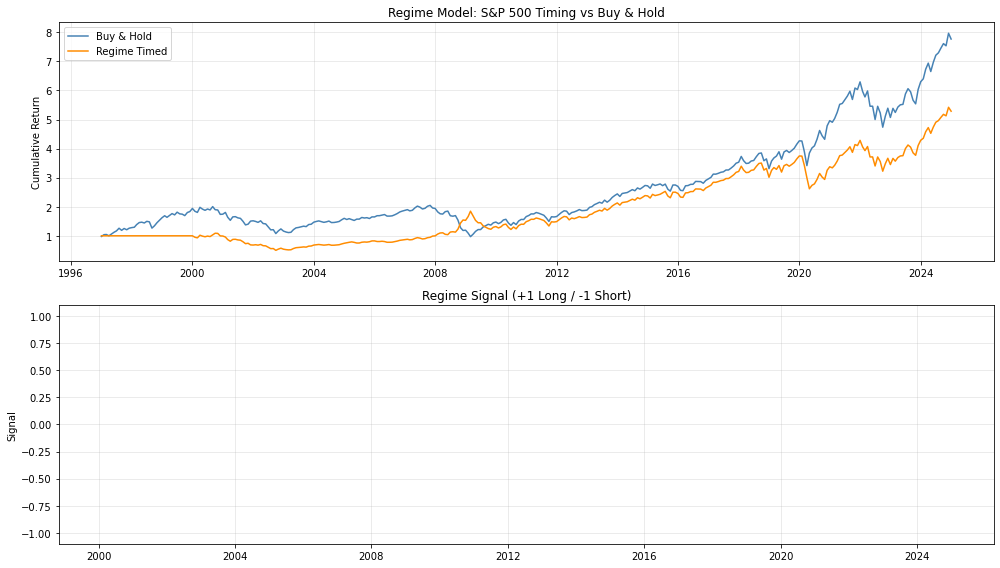

Saved regime_signal.csv and regime_scores.csv


In [3]:
"""
Regime Model - Replication of Man Group Paper
===============================================
Step 1: Transform variables to z-scores (12m change, rolling 10yr, winsorized ±3)
Step 2: Compute Euclidean distance (Global Score) for each historical month
Step 3: Generate similarity-based signal for any target asset
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load data ─────────────────────────────────────────────────────────────────
data = pd.read_csv("data/regime_raw_data.csv", index_col=0, parse_dates=True)
factors = pd.read_csv("data/ff_factors_monthly.csv", index_col=0, parse_dates=True)
sp500_monthly = pd.read_csv("data/sp500_crsp.csv", index_col=0, parse_dates=True).squeeze()
print(f"Loaded: data {data.shape}, factors {factors.shape}")


# ──────────────────────────────────────────────────────────────────────────────
# STEP 1: Transform variables to z-scores
# Paper: 12-month change, normalized by rolling 10yr std, winsorized at ±3
# ──────────────────────────────────────────────────────────────────────────────

ROLLING_WINDOW = 120   # 10 years of monthly data
WINSOR_LIMIT   = 3.0

def transform_to_zscore(series: pd.Series) -> pd.Series:
    """
    1. Compute 12-month change
    2. Divide by rolling 10yr std of those changes (z-score)
    3. Winsorize at ±3
    """
    change  = series.diff(12)                               # 12-month difference
    std     = change.rolling(ROLLING_WINDOW).std()          # rolling 10yr std
    zscore  = change / std                                  # normalize
    zscore  = zscore.clip(-WINSOR_LIMIT, WINSOR_LIMIT)      # winsorize
    return zscore

transformed = data.apply(transform_to_zscore)
transformed = transformed.dropna()

print(f"Transformed data: {transformed.shape}")
print(f"Date range after transformation: {transformed.index[0].date()} → {transformed.index[-1].date()}\n")


# ──────────────────────────────────────────────────────────────────────────────
# STEP 2: Compute Global Score (Euclidean distance)
# For each month T, compute distance to every historical month i
# Exclude last 36 months from similar set (avoid momentum loading)
# ──────────────────────────────────────────────────────────────────────────────

MASK_MONTHS = 36   # exclude most recent 3 years from similarity search

def compute_global_scores(transformed: pd.DataFrame) -> pd.DataFrame:
    """
    For each month T, compute Euclidean distance to all prior months i.
    Returns a DataFrame where scores[T, i] = distance between month T and month i.
    Lower score = more similar.
    """
    values = transformed.values       # shape: (T, n_vars)
    n      = len(transformed)
    scores = np.full((n, n), np.nan)

    for t in range(n):
        # only look at history (no future, exclude last 36 months)
        max_i = max(0, t - MASK_MONTHS)
        if max_i == 0:
            continue
        x_t = values[t]               # today's z-scores
        x_h = values[:max_i]          # historical z-scores

        # Euclidean distance: sqrt of sum of squared differences
        diffs        = x_h - x_t      # shape: (max_i, n_vars)
        sq_distances = np.sum(diffs**2, axis=1)
        distances    = np.sqrt(sq_distances)
        scores[t, :max_i] = distances

    return pd.DataFrame(scores, index=transformed.index, columns=transformed.index)

print("Computing Global Scores (this takes ~30 seconds)...")
scores = compute_global_scores(transformed)
print("Done.\n")


# ──────────────────────────────────────────────────────────────────────────────
# STEP 3: Generate similarity signal for a target asset
# - Find the 20% most similar historical months (quintile 1)
# - Look at asset returns in the month AFTER those similar periods
# - Go long if avg return is positive, short if negative
# ──────────────────────────────────────────────────────────────────────────────

SIMILARITY_QUANTILE = 0.20    # top 20% most similar = quintile 1

def compute_regime_signal(scores: pd.DataFrame,
                           asset_returns: pd.Series,
                           quantile: float = SIMILARITY_QUANTILE) -> pd.Series:
    """
    For each month T:
      1. Get similarity scores to all historical months
      2. Select the most similar months (lowest scores, bottom quantile)
      3. Look at asset returns in the month AFTER those similar months
      4. Signal = +1 if avg return > 0, -1 if avg return < 0, 0 if no data
    """
    signals = {}

    for t in scores.index:
        row = scores.loc[t].dropna()
        if len(row) == 0:
            signals[t] = 0
            continue

        # threshold for "similar" = bottom quantile of distances
        threshold    = row.quantile(quantile)
        similar_dates = row[row <= threshold].index

        # get returns in the month AFTER each similar date
        future_returns = []
        for d in similar_dates:
            # find next month in asset_returns after d
            future = asset_returns[asset_returns.index > d]
            if len(future) > 0:
                future_returns.append(future.iloc[0])

        if len(future_returns) == 0:
            signals[t] = 0
        else:
            avg_return = np.mean(future_returns)
            signals[t] = 1 if avg_return > 0 else -1

    return pd.Series(signals, name="regime_signal")


# ── Apply to S&P 500 as a demo ────────────────────────────────────────────────
print("Computing S&P 500 monthly returns...")
sp500_returns = data["sp500"].pct_change().dropna()

# align to transformed index
sp500_returns = sp500_returns.reindex(transformed.index)

print("Generating regime signal for S&P 500...")
signal = compute_regime_signal(scores, sp500_returns)

print(f"\nSignal distribution:\n{signal.value_counts()}\n")


# ── Backtest: timed strategy vs buy & hold ────────────────────────────────────
backtest = pd.DataFrame({
    "returns"      : sp500_returns,
    "signal"       : signal,
}).dropna()

backtest["timed_returns"]   = backtest["signal"] * backtest["returns"]
backtest["cumulative_bh"]   = (1 + backtest["returns"]).cumprod()
backtest["cumulative_timed"]= (1 + backtest["timed_returns"]).cumprod()

# ── Performance metrics ───────────────────────────────────────────────────────
def sharpe(returns, periods=12):
    return (returns.mean() / returns.std()) * np.sqrt(periods)

print("=== Performance Summary ===")
print(f"Buy & Hold  Sharpe: {sharpe(backtest['returns']):.2f}")
print(f"Timed       Sharpe: {sharpe(backtest['timed_returns']):.2f}")
print(f"Buy & Hold  Ann. Return: {backtest['returns'].mean()*12*100:.1f}%")
print(f"Timed       Ann. Return: {backtest['timed_returns'].mean()*12*100:.1f}%")


# ── Plot ──────────────────────────────────────────────────────────────────────
idx = backtest.index.to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(idx, backtest["cumulative_bh"].to_numpy(),
             label="Buy & Hold", linewidth=1.5, color="steelblue")
axes[0].plot(idx, backtest["cumulative_timed"].to_numpy(),
             label="Regime Timed", linewidth=1.5, color="darkorange")
axes[0].set_title("Regime Model: S&P 500 Timing vs Buy & Hold")
axes[0].set_ylabel("Cumulative Return")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(idx, backtest["signal"].to_numpy(),
            color=["green" if s > 0 else "red" for s in backtest["signal"]],
            alpha=0.6, width=25)
axes[1].set_title("Regime Signal (+1 Long / -1 Short)")
axes[1].set_ylabel("Signal")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("regime_backtest.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Save signal ───────────────────────────────────────────────────────────────
signal.to_csv("regime_signal.csv")
scores.to_csv("regime_scores.csv")
print("Saved regime_signal.csv and regime_scores.csv")

In [4]:
print(backtest[["cumulative_bh", "cumulative_timed"]].tail(10))
print("\n=== Performance Summary ===")
print(f"Buy & Hold  Sharpe: {sharpe(backtest['returns']):.2f}")
print(f"Timed       Sharpe: {sharpe(backtest['timed_returns']):.2f}")
print(f"Buy & Hold  Ann. Return: {backtest['returns'].mean()*12*100:.1f}%")
print(f"Timed       Ann. Return: {backtest['timed_returns'].mean()*12*100:.1f}%")

            cumulative_bh  cumulative_timed
2024-03-31       6.940834          4.722187
2024-04-30       6.651991          4.525673
2024-05-31       6.971427          4.743001
2024-06-30       7.213125          4.907440
2024-07-31       7.294787          4.962999
2024-08-31       7.461362          5.076327
2024-09-30       7.612058          5.178853
2024-10-31       7.536723          5.127599
2024-11-30       7.968587          5.421418
2024-12-31       7.769451          5.285936

=== Performance Summary ===
Buy & Hold  Sharpe: 0.55
Timed       Sharpe: 0.48
Buy & Hold  Ann. Return: 8.5%
Timed       Ann. Return: 7.0%


Computing quintile signals for all 6 factors...
(This takes a few minutes — 2 quintiles x 6 factors)

  Processing Market...
  Processing Size...
  Processing Value...
  Processing Profitability...
  Processing Investment...
  Processing Momentum...

=== Performance Summary ===
Strategy                    Sharpe    Ann Ret     Max DD
-------------------------------------------------------
Long-Only Benchmark           0.79       3.6%     -12.4%
Quintile 1 (Similar)          0.51       2.3%     -13.6%
Quintile 5 (Dissimilar)      -0.16      -0.7%     -40.2%
Difference (Q1-Q5)            0.48       3.0%     -20.6%

Corr(Q1, Long-Only):   0.30
Corr(Diff, Long-Only): -0.05


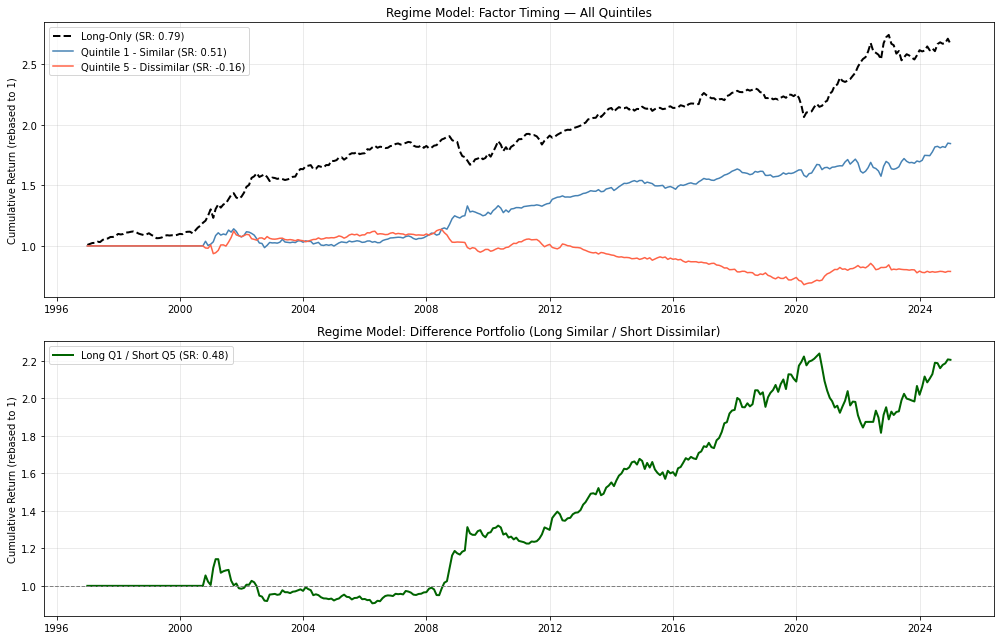


Plot saved to regime_ff_backtest.png


In [5]:
"""
Regime Model - Fama-French Factor Timing + Difference Portfolio
================================================================
Replicates the core result of the Man Group paper:
  - Apply regime signal to 6 FF factors
  - Long quintile 1 (most similar), Short quintile 5 (most dissimilar)
  - Compare difference portfolio vs long-only benchmark
"""

import pandas as pd
import numpy as np
import urllib.request
import zipfile
import io
import matplotlib.pyplot as plt



# ──────────────────────────────────────────────────────────────────────────────
# STEP 2: Generate quintile signals for each factor
# Quintile 1 = 20% most similar, Quintile 5 = 20% most dissimilar
# ──────────────────────────────────────────────────────────────────────────────

def compute_quintile_signal(scores: pd.DataFrame,
                             factor_returns: pd.Series,
                             quintile: int = 1) -> pd.Series:
    """
    For each month T:
      - Get similarity scores to all historical months
      - Quintile 1: bottom 20% distances (most similar)
      - Quintile 5: top 20% distances (most dissimilar)
      - Signal = +1 if avg subsequent return > 0, else -1
    """
    assert quintile in [1, 2, 3, 4, 5], "quintile must be 1-5"

    signals = {}
    q_low  = (quintile - 1) * 0.20
    q_high = quintile       * 0.20

    for t in scores.index:
        row = scores.loc[t].dropna()
        row = row[row > 0]           # remove zeros (self-distance)
        if len(row) < 10:
            signals[t] = 0
            continue

        lo = row.quantile(q_low)  if q_low  > 0 else -np.inf
        hi = row.quantile(q_high)

        selected_dates = row[(row > lo) & (row <= hi)].index

        future_returns = []
        for d in selected_dates:
            future = factor_returns[factor_returns.index > d]
            if len(future) > 0:
                future_returns.append(future.iloc[0])

        if len(future_returns) == 0:
            signals[t] = 0
        else:
            avg = np.mean(future_returns)
            signals[t] = 1 if avg > 0 else -1

    return pd.Series(signals, name=f"q{quintile}_signal")


# align scores to factor date range
common_idx = scores.index.intersection(factors.index)
scores_aligned = scores.loc[common_idx]

print("Computing quintile signals for all 6 factors...")
print("(This takes a few minutes — 2 quintiles x 6 factors)\n")

q1_signals = {}
q5_signals = {}

for factor in factors.columns:
    print(f"  Processing {factor}...")
    f_returns = factors[factor]
    q1_signals[factor] = compute_quintile_signal(scores_aligned, f_returns, quintile=1)
    q5_signals[factor] = compute_quintile_signal(scores_aligned, f_returns, quintile=5)

q1_df = pd.DataFrame(q1_signals)
q5_df = pd.DataFrame(q5_signals)


# ──────────────────────────────────────────────────────────────────────────────
# STEP 3: Build portfolios
# Quintile 1 portfolio: equal-weight timed factors using Q1 signal
# Quintile 5 portfolio: equal-weight timed factors using Q5 signal
# Long-only benchmark: always long all 6 factors equally
# Difference portfolio: long Q1, short Q5
# ──────────────────────────────────────────────────────────────────────────────

# align everything
idx = q1_df.index.intersection(factors.index)
q1_df      = q1_df.loc[idx]
q5_df      = q5_df.loc[idx]
factors_aligned = factors.loc[idx]

# timed returns = signal * factor return
q1_returns   = (q1_df * factors_aligned).mean(axis=1)   # equal weight across 6 factors
q5_returns   = (q5_df * factors_aligned).mean(axis=1)
lo_returns   = factors_aligned.mean(axis=1)              # long-only benchmark
diff_returns = q1_returns - q5_returns                   # difference portfolio


# ── Performance metrics ───────────────────────────────────────────────────────
def sharpe(returns, periods=12):
    return (returns.mean() / returns.std()) * np.sqrt(periods)

def max_drawdown(returns):
    cum = (1 + returns).cumprod()
    roll_max = cum.cummax()
    dd = (cum - roll_max) / roll_max
    return dd.min()

def ann_return(returns, periods=12):
    return returns.mean() * periods

print("\n=== Performance Summary ===")
print(f"{'Strategy':<25} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 55)
for name, ret in [("Long-Only Benchmark", lo_returns),
                   ("Quintile 1 (Similar)", q1_returns),
                   ("Quintile 5 (Dissimilar)", q5_returns),
                   ("Difference (Q1-Q5)", diff_returns)]:
    print(f"{name:<25} {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:>9.1f}%")

# correlation of Q1 and diff with long-only
print(f"\nCorr(Q1, Long-Only):   {q1_returns.corr(lo_returns):.2f}")
print(f"Corr(Diff, Long-Only): {diff_returns.corr(lo_returns):.2f}")


# ── Plot ──────────────────────────────────────────────────────────────────────
cum_lo   = (1 + lo_returns).cumprod()
cum_q1   = (1 + q1_returns).cumprod()
cum_q5   = (1 + q5_returns).cumprod()
cum_diff = (1 + diff_returns).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# left chart equivalent: all quintiles vs long-only
idx_np = cum_lo.index.to_numpy()
axes[0].plot(idx_np, cum_lo.to_numpy(),   label=f"Long-Only (SR: {sharpe(lo_returns):.2f})",
             linewidth=2, color="black", linestyle="--")
axes[0].plot(idx_np, cum_q1.to_numpy(),   label=f"Quintile 1 - Similar (SR: {sharpe(q1_returns):.2f})",
             linewidth=1.5, color="steelblue")
axes[0].plot(idx_np, cum_q5.to_numpy(),   label=f"Quintile 5 - Dissimilar (SR: {sharpe(q5_returns):.2f})",
             linewidth=1.5, color="tomato")
axes[0].set_title("Regime Model: Factor Timing — All Quintiles")
axes[0].set_ylabel("Cumulative Return (rebased to 1)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# right chart equivalent: difference portfolio
axes[1].plot(cum_diff.index.to_numpy(), cum_diff.to_numpy(),
             label=f"Long Q1 / Short Q5 (SR: {sharpe(diff_returns):.2f})",
             linewidth=2, color="darkgreen")
axes[1].axhline(1, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Regime Model: Difference Portfolio (Long Similar / Short Dissimilar)")
axes[1].set_ylabel("Cumulative Return (rebased to 1)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("regime_ff_backtest.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved to regime_ff_backtest.png")

In [6]:
# ── Load S&P 500 returns for comparison ───────────────────────────────────────
sp500_returns = data["sp500"].pct_change().dropna()
sp500_aligned = sp500_returns.reindex(common_idx).dropna()

# ── Compare all strategies ────────────────────────────────────────────────────
print("=== Full Comparison ===")
print(f"{'Strategy':<25} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 55)
for name, ret in [("S&P 500 Buy & Hold",   sp500_aligned),
                   ("FF Long-Only",          lo_returns),
                   ("Difference (Q1-Q5)",    diff_returns),
                   ("Quintile 1 (Similar)",  q1_returns)]:
    print(f"{name:<25} {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:>9.1f}%")

# ── What regime are we in RIGHT NOW? ─────────────────────────────────────────
print("\n=== Current Regime Analysis ===")
latest_date = scores.index[-1]
latest_scores = scores.loc[latest_date].dropna()
latest_scores = latest_scores[latest_scores > 0]

# most similar historical periods
n_similar = int(len(latest_scores) * 0.20)
most_similar = latest_scores.nsmallest(n_similar)
most_dissimilar = latest_scores.nlargest(n_similar)

print(f"Current date in model: {latest_date.date()}")
print(f"\nTop 10 most similar historical periods:")
print(most_similar.head(10).index.strftime("%Y-%m").tolist())

print(f"\nTop 10 most dissimilar historical periods:")
print(most_dissimilar.head(10).index.strftime("%Y-%m").tolist())

# current signal for each factor
print("\n=== Current Signal per Factor ===")
for factor in factors.columns:
    sig = q1_df[factor].iloc[-1]
    direction = "LONG" if sig == 1 else "SHORT" if sig == -1 else "NEUTRAL"
    print(f"  {factor:<15}: {direction}")

=== Full Comparison ===
Strategy                    Sharpe    Ann Ret     Max DD
-------------------------------------------------------
S&P 500 Buy & Hold            0.55       8.5%     -52.6%
FF Long-Only                  0.79       3.6%     -12.4%
Difference (Q1-Q5)            0.48       3.0%     -20.6%
Quintile 1 (Similar)          0.51       2.3%     -13.6%

=== Current Regime Analysis ===
Current date in model: 2024-12-31

Top 10 most similar historical periods:
['2020-11', '2010-05', '2011-07', '2021-01', '2020-12', '2010-06', '2010-07', '2020-08', '2011-02', '2011-03']

Top 10 most dissimilar historical periods:
['2008-12', '2009-02', '2009-01', '2008-11', '2001-03', '2008-10', '2009-03', '2001-09', '2009-04', '2000-12']

=== Current Signal per Factor ===
  Market         : LONG
  Size           : LONG
  Value          : SHORT
  Profitability  : LONG
  Investment     : SHORT
  Momentum       : LONG


=== Factor Portfolio: Regime Tilt vs Benchmarks ===
Strategy                         Sharpe    Ann Ret     Max DD
------------------------------------------------------------
S&P 500 Buy & Hold                 0.56       8.6%     -52.6%
Equal Weight Factors               0.79       3.6%     -12.4%
Regime Tilted Factors              0.76       3.9%     -13.5%

Corr(Tilt, Equal Weight): 0.87
Corr(Tilt, S&P 500):      0.29

=== Current Portfolio Weights (based on latest signal) ===
  Market         :  22.7%  (LONG ↑)
  Size           :  22.7%  (LONG ↑)
  Value          :   4.5%  (SHORT ↓)
  Profitability  :  22.7%  (LONG ↑)
  Investment     :   4.5%  (SHORT ↓)
  Momentum       :  22.7%  (LONG ↑)


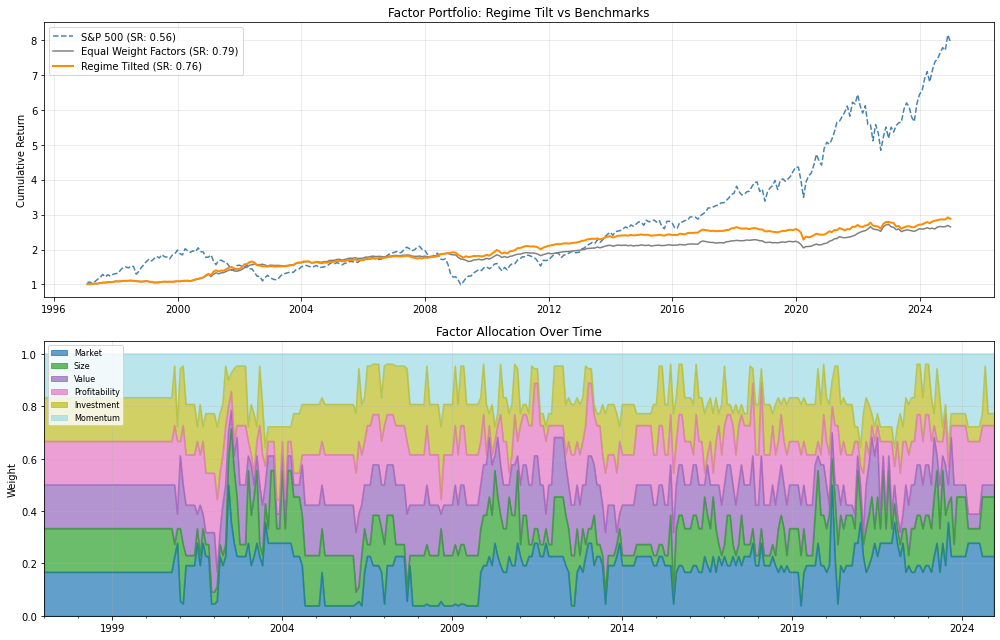

In [7]:
# ── Factor ETF Portfolio with Regime Tilts ────────────────────────────────────
# Base: equal weight across 6 factors
# Tilt: overweight LONG signals, underweight SHORT signals

BASE_WEIGHT  = 1/6        # 16.7% each
LONG_WEIGHT  = 0.25       # overweight to 25%
SHORT_WEIGHT = 0.05       # underweight to 5%

def compute_factor_weights(signals_row: pd.Series) -> pd.Series:
    """Convert signals (+1/-1/0) to portfolio weights that sum to 1."""
    weights = {}
    for factor, sig in signals_row.items():
        if sig == 1:
            weights[factor] = LONG_WEIGHT
        elif sig == -1:
            weights[factor] = SHORT_WEIGHT
        else:
            weights[factor] = BASE_WEIGHT
    # normalize to sum to 1
    total = sum(weights.values())
    return pd.Series({k: v/total for k, v in weights.items()})

# compute weights for each month using Q1 signals
weights_df = q1_df.apply(compute_factor_weights, axis=1)

# align factors and weights
strat_idx      = weights_df.index.intersection(factors.index)
weights_aligned = weights_df.reindex(strat_idx).shift(1).dropna()  # shift 1 to avoid lookahead
factors_aligned = factors.reindex(weights_aligned.index)
sp500_aligned   = sp500_returns.reindex(weights_aligned.index).dropna()

# portfolio return = sum of (weight * factor return) each month
tilt_returns   = (weights_aligned * factors_aligned).sum(axis=1)
equal_returns  = factors_aligned.mean(axis=1)            # equal weight benchmark
sp500_ret_plot = sp500_aligned.reindex(tilt_returns.index)

# ── Performance ───────────────────────────────────────────────────────────────
print("=== Factor Portfolio: Regime Tilt vs Benchmarks ===")
print(f"{'Strategy':<30} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 60)
for name, ret in [("S&P 500 Buy & Hold",        sp500_ret_plot),
                   ("Equal Weight Factors",      equal_returns),
                   ("Regime Tilted Factors",     tilt_returns)]:
    print(f"{name:<30} {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:>9.1f}%")

print(f"\nCorr(Tilt, Equal Weight): {tilt_returns.corr(equal_returns):.2f}")
print(f"Corr(Tilt, S&P 500):      {tilt_returns.corr(sp500_ret_plot):.2f}")

# ── Current weights ───────────────────────────────────────────────────────────
print("\n=== Current Portfolio Weights (based on latest signal) ===")
current_weights = weights_df.iloc[-1]
for factor, w in current_weights.items():
    signal_str = "LONG ↑" if q1_df[factor].iloc[-1] == 1 else "SHORT ↓" if q1_df[factor].iloc[-1] == -1 else "NEUTRAL"
    print(f"  {factor:<15}: {w*100:>5.1f}%  ({signal_str})")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

cum_sp  = (1 + sp500_ret_plot).cumprod()
cum_eq  = (1 + equal_returns).cumprod()
cum_tlt = (1 + tilt_returns).cumprod()
idx_np  = cum_tlt.index.to_numpy()

axes[0].plot(idx_np, cum_sp.to_numpy(),  label=f"S&P 500 (SR: {sharpe(sp500_ret_plot):.2f})",
             color="steelblue",  linewidth=1.5, linestyle="--")
axes[0].plot(idx_np, cum_eq.to_numpy(),  label=f"Equal Weight Factors (SR: {sharpe(equal_returns):.2f})",
             color="gray",       linewidth=1.5)
axes[0].plot(idx_np, cum_tlt.to_numpy(), label=f"Regime Tilted (SR: {sharpe(tilt_returns):.2f})",
             color="darkorange", linewidth=2)
axes[0].set_title("Factor Portfolio: Regime Tilt vs Benchmarks")
axes[0].set_ylabel("Cumulative Return")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# weights over time
weights_aligned.plot.area(ax=axes[1], stacked=True, alpha=0.7,
                           colormap="tab20")
axes[1].set_title("Factor Allocation Over Time")
axes[1].set_ylabel("Weight")
axes[1].legend(loc="upper left", fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("regime_factor_portfolio.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ── Long-only top factors, avoid bottom factors ───────────────────────────────
# Each month: only hold factors with LONG signal
# If all signals are flat, hold equal weight
# Compare against S&P 500

def compute_longonly_weights(signals_row: pd.Series) -> pd.Series:
    long_factors = [f for f, s in signals_row.items() if s == 1]
    if len(long_factors) == 0:
        # fallback to equal weight if no longs
        return pd.Series({f: 1/len(signals_row) for f in signals_row.index})
    weight = 1 / len(long_factors)
    return pd.Series({f: weight if f in long_factors else 0.0
                      for f in signals_row.index})

weights_lo    = q1_df.apply(compute_longonly_weights, axis=1)
weights_lo_al = weights_lo.reindex(strat_idx).shift(1).dropna()
factors_lo    = factors.reindex(weights_lo_al.index)
sp500_lo      = sp500_returns.reindex(weights_lo_al.index)

longonly_tilt = (weights_lo_al * factors_lo).sum(axis=1)

print("=== Long Best Factors Only vs S&P 500 ===")
print(f"{'Strategy':<30} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 60)
for name, ret in [("S&P 500 Buy & Hold",     sp500_lo),
                   ("Equal Weight Factors",   factors_lo.mean(axis=1)),
                   ("Long Best Factors Only", longonly_tilt)]:
    print(f"{name:<30} {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:>9.1f}%")

# how many factors are held each month on average
avg_factors_held = (weights_lo_al > 0).sum(axis=1).mean()
print(f"\nAvg factors held per month: {avg_factors_held:.1f}")
print(f"Corr(Strategy, S&P 500): {longonly_tilt.corr(sp500_lo):.2f}")

=== Long Best Factors Only vs S&P 500 ===
Strategy                         Sharpe    Ann Ret     Max DD
------------------------------------------------------------
S&P 500 Buy & Hold                 0.56       8.6%     -52.6%
Equal Weight Factors               0.79       3.6%     -12.4%
Long Best Factors Only             0.60       3.7%     -18.7%

Avg factors held per month: 4.6
Corr(Strategy, S&P 500): 0.32


In [9]:
# ── Long/Short S&P 500 using regime signal ────────────────────────────────────
# Q1 signal on S&P 500 = LONG
# Q5 signal on S&P 500 = SHORT  
# Neither = cash (0)

# recompute Q1 and Q5 signals specifically for S&P 500
print("Computing Q1 and Q5 signals for S&P 500...")
sp500_q1 = compute_quintile_signal(scores_aligned, sp500_returns, quintile=1)
sp500_q5 = compute_quintile_signal(scores_aligned, sp500_returns, quintile=5)

# combined signal: +1 if Q1=long, -1 if Q5=short, 0 if neither or conflicting
combined_signal = pd.Series(0, index=sp500_q1.index)
combined_signal[sp500_q1 == 1]  =  1
combined_signal[sp500_q5 == -1] = -1

# align
sig_idx      = combined_signal.index.intersection(sp500_returns.index)
sig_aligned  = combined_signal.reindex(sig_idx).shift(1).dropna()
sp500_sig    = sp500_returns.reindex(sig_aligned.index)

ls_returns   = sig_aligned * sp500_sig

print("=== Long/Short S&P 500 vs Buy & Hold ===")
print(f"{'Strategy':<30} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 60)
for name, ret in [("S&P 500 Buy & Hold",    sp500_sig),
                   ("L/S S&P 500",           ls_returns)]:
    print(f"{name:<30} {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:>9.1f}%")

print(f"\nSignal distribution:")
print(sig_aligned.value_counts())
print(f"\nCorr(L/S, S&P 500): {ls_returns.corr(sp500_sig):.2f}")

Computing Q1 and Q5 signals for S&P 500...
=== Long/Short S&P 500 vs Buy & Hold ===
Strategy                         Sharpe    Ann Ret     Max DD
------------------------------------------------------------
S&P 500 Buy & Hold                 0.56       8.6%     -52.6%
L/S S&P 500                       -0.05      -0.7%     -63.1%

Signal distribution:
 1.0    126
-1.0    124
 0.0     86
Name: count, dtype: int64

Corr(L/S, S&P 500): 0.16


In [10]:
# Long when similar (Q1=long), Cash when dissimilar (Q5=short)
# No shorting — just sidestep bad regimes

cash_signal = sp500_q1.reindex(sig_idx).shift(1).dropna()
# 1 = long SP500, 0 = cash (Q5 or neutral)
cash_signal_binary = (cash_signal == 1).astype(int)

cash_returns = cash_signal_binary * sp500_sig

print("=== Market Timing vs Buy & Hold ===")
print(f"{'Strategy':<30} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 60)
for name, ret in [("S&P 500 Buy & Hold",  sp500_sig),
                   ("Regime Market Timing", cash_returns)]:
    print(f"{name:<30} {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:>9.1f}%")

print(f"\nMonths invested: {cash_signal_binary.sum()} / {len(cash_signal_binary)}")

=== Market Timing vs Buy & Hold ===
Strategy                         Sharpe    Ann Ret     Max DD
------------------------------------------------------------
S&P 500 Buy & Hold                 0.56       8.6%     -52.6%
Regime Market Timing               0.54       6.8%     -37.5%

Months invested: 247 / 336


In [12]:
# ============================================================
# Save results for notebook 03
# ============================================================
import os
os.makedirs("data", exist_ok=True)

# Regime similarity scores (the core output of the regime model)
scores.to_csv("data/regime_scores.csv")


# Helper functions will be redefined in notebook 03
print(f"Saved regime_scores.csv ({scores.shape})")

Saved regime_scores.csv ((337, 337))


In [13]:
# S&P 500 monthly returns
sp500_returns.to_csv("data/sp500_returns_monthly.csv")